>
> # Scenario analysis
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [27]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
from scenarios import *
from plot_func import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Enter variable and data type
variable = {"name": "gini", "sym": "$G$", "int": False}

In [4]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variable["name"])
res, micro, params, drivers, requests, var_val = load_results(dir_name)

# Find variable values that have been tested
vals, scn = find_vals(var_val, variable)

# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators(micro, params, drivers, requests, res)

In [5]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl.head(10)

all replications have converged


,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged
0,45,89.563591,44,815.692540,45,True
1,64,90.696727,36,674.397004,64,True
2,80,89.867377,30,527.019933,80,True
3,62,90.492878,29,524.845267,62,True
4,66,89.488670,40,573.209860,66,True
5,57,88.052708,22,672.543517,57,True
6,51,87.845409,39,681.687905,51,True
7,109,81.001057,31,546.266003,109,True
8,77,87.423307,40,612.659343,77,True
9,34,91.715356,27,591.160608,34,True


In [6]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 10/5 for scenario 0.25
Sufficient number of replications: 10/2 for scenario 0.35
Sufficient number of replications: 10/4 for scenario 0.45
Sufficient number of replications: 10/3 for scenario 0.55
Sufficient number of replications: 10/1 for scenario 0.65


In [7]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [8]:
eql_scn.dem

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,pt,vot_inf,vot_req,std_perc_wait,std_exp_wait,std_corr_wait,std_perc_wait_req,GC_diff
scenario,,,,,,,,,,,,,,,,,,
0.25,7058.9,258.80,0.992564,256.84,339.927193,350.052274,687.124443,322.088592,5083.62,1257.36,459.12,16.134257,16.798249,4269.812837,247.298559,267.167869,161.028875,-4659.814422
0.35,7378.8,405.00,1.000000,405.00,230.445456,230.445456,426.811212,224.871960,5055.24,1473.70,444.86,19.035234,23.148464,2066.143410,181.713977,181.713977,118.873099,-5929.370686
0.45,7171.0,595.86,1.000000,595.86,160.058797,160.058797,276.035510,162.652738,4624.44,1553.88,396.82,22.624529,35.015251,994.840751,138.697871,138.697871,93.481084,-5657.250274
0.55,6659.5,837.70,1.000000,837.70,111.886106,111.886106,180.194493,117.359651,4020.18,1462.30,339.32,27.317696,51.791298,447.827073,106.677858,106.677858,73.028345,-2532.969701
0.65,5922.3,969.36,1.000000,969.36,90.581566,90.581566,133.495448,92.799768,3503.68,1196.32,252.94,33.903145,71.881488,280.870414,92.242654,92.242654,65.272231,3663.879375


In [9]:
eql_scn.sup

,inform,regist,particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,rel_perc_inc_reg,rel_perc_inc_ptcp,std_perc_inc,std_exp_inc,std_perc_inc_reg,std_perc_inc_ptcp,res_wage_inf,res_wage_reg,res_wage_ptcp,new_regist,deregist,surplus
scenario,,,,,,,,,,,,,,,,,,,,
0.25,1000.0,42.76,15.36,85.281589,85.986653,85.873086,86.349750,0.520610,0.861199,1.402822,7.203158,17.218172,7.531976,6.691982,201.011716,148.844827,63.459349,1.82,2.12,-527.098342
0.35,1000.0,56.36,32.74,71.456128,72.676108,71.546042,71.399117,0.532526,1.285632,1.812222,6.150516,22.941875,8.298259,8.376226,202.830342,113.966532,43.664577,2.42,2.62,-247.829327
0.45,1000.0,86.74,59.74,60.226001,61.368006,60.238343,61.113749,0.604608,1.770792,2.276391,5.456480,23.638339,8.566514,8.358380,204.135146,77.274567,31.254041,3.32,3.40,31.352050
0.55,1000.0,128.74,101.92,51.751704,52.713634,51.950922,52.062161,0.811539,2.644814,3.103445,5.151057,21.979932,8.560826,8.486708,203.626025,58.064945,22.008446,3.94,3.72,477.348569
0.65,1000.0,170.38,140.76,43.535455,44.488131,43.799540,44.135060,1.191294,3.944851,4.499451,4.971642,20.419068,8.399365,8.299630,197.384020,46.972552,15.085587,4.36,4.88,673.908818


In [10]:
eql_scn.plf

,profit
0.25,617.008595
0.35,1028.898634
0.45,1569.911447
0.55,2243.169754
0.65,2606.901567


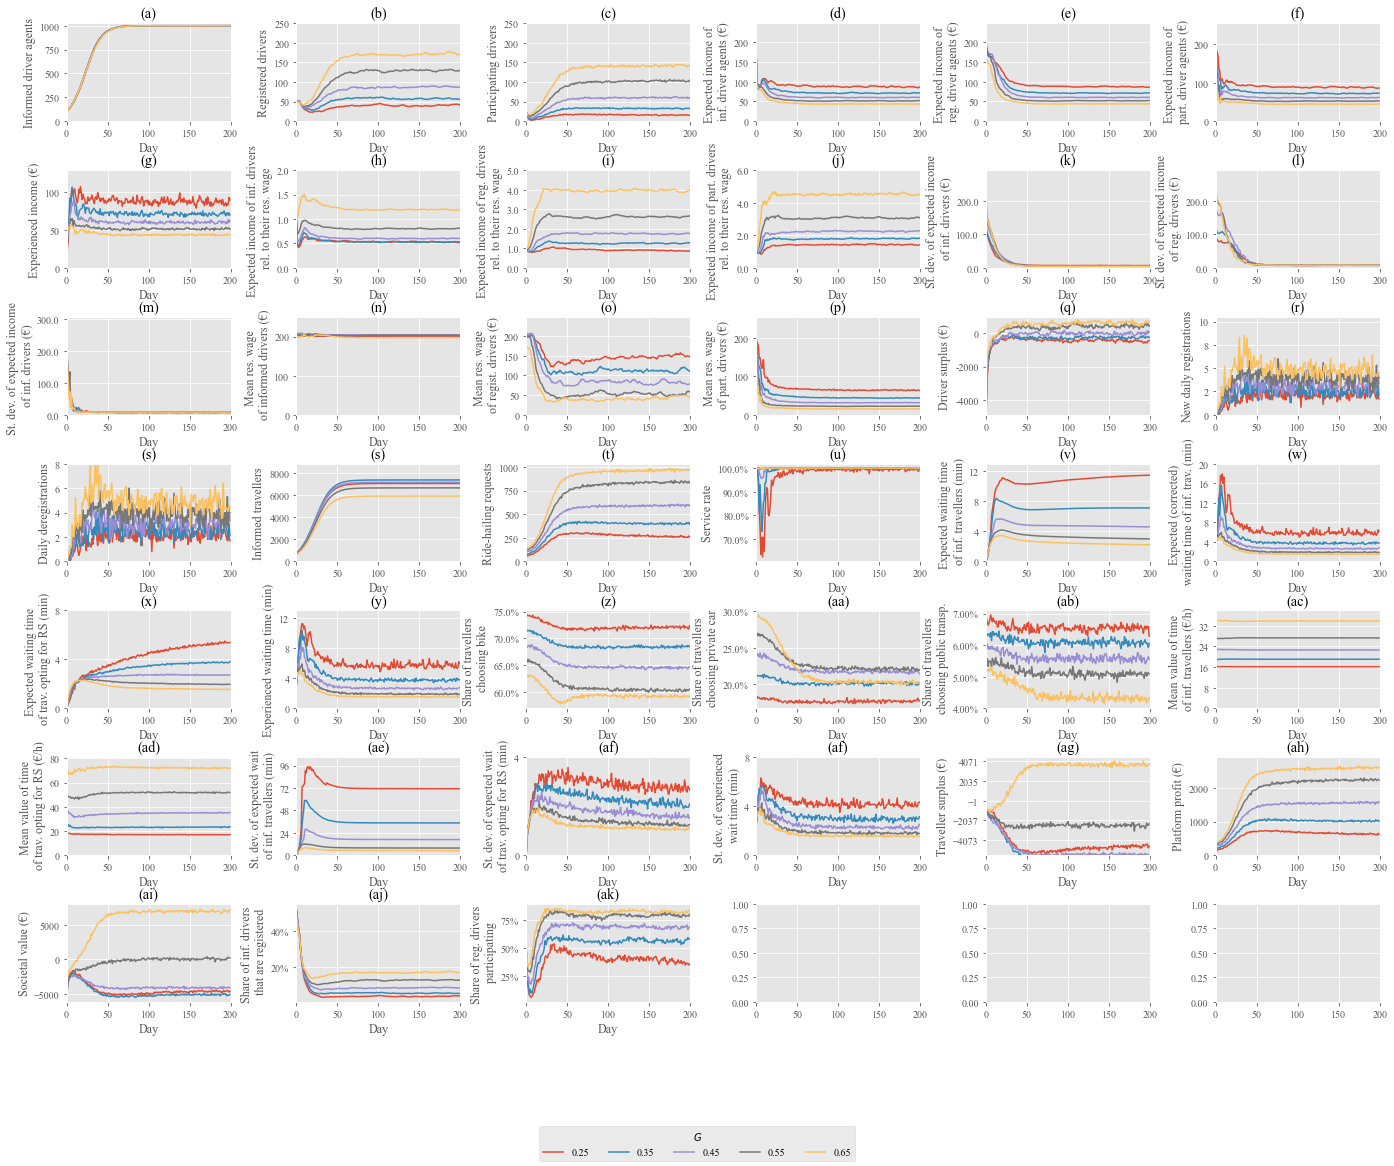

In [23]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals, variable)
fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], variable["name"] + '_multi_fig.jpg'),dpi=300,bbox_inches='tight')

<AxesSubplot:xlabel='day', ylabel='Volume of informed drivers'>

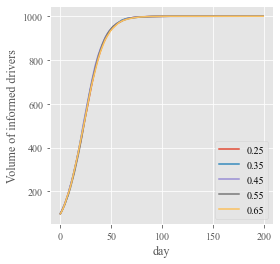

In [24]:
# Plot an individual indicator
plot_inform = res_scn.sup.inform.plot()
plot_inform.set_ylabel("Volume of informed drivers")
plot_inform

In [255]:
# kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
# kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
# kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
# kpi_eq.requests = round(kpi_eq.requests).astype(int)
# kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
# kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
# kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
# kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
# kpi_eq.service_rate = round(kpi_eq.service_rate,1)
# kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
# kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
# kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
# kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
# kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
# kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
# kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# # kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
# kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]

# Print equilibrium indicators as LateX table
print(eql_scn.sup.astype('str').T.to_latex(index=True))
print(eql_scn.dem.astype('str').T.to_latex(index=True))
print(eql_scn.plf.astype('str').T.to_latex(index=True))

\begin{tabular}{llllll}
\toprule
scenario &                0.25 &                 0.35 &                0.45 &                0.55 &                0.65 \\
\midrule
inform             &              1000.0 &               1000.0 &              1000.0 &              1000.0 &              1000.0 \\
regist             &               42.76 &                56.36 &               86.74 &              128.74 &              170.38 \\
particip           &               15.36 &   32.739999999999995 &  59.739999999999995 &              101.92 &              140.76 \\
mean\_perc\_inc      &   85.28158932890878 &    71.45612835012172 &   60.22600060137235 &   51.75170370082189 &   43.53545507745488 \\
mean\_perc\_inc\_ptcp &   85.98665292755241 &    72.67610791896988 &   61.36800615624837 &   52.71363428119747 &   44.48813113862909 \\
mean\_perc\_inc\_reg  &   85.87308555759016 &     71.5460419957204 &    60.2383425983816 &  51.950921503036284 &   43.79953992771725 \\
mean\_exp\_inc       &   86.3

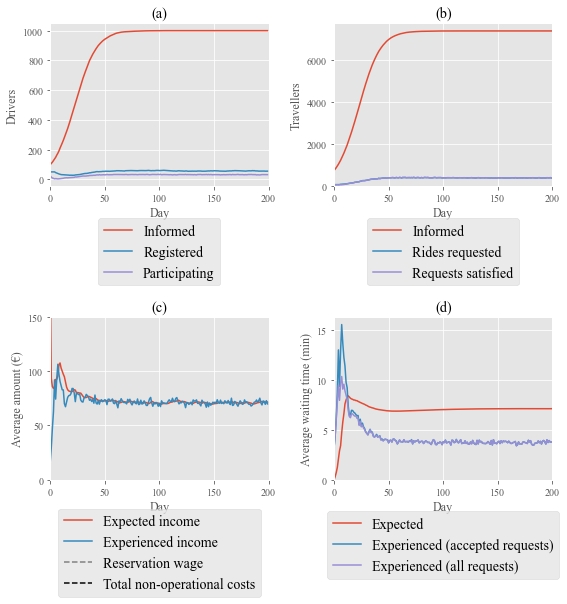

In [28]:
# Plot indicators for single scenario (e.g. base scenario)
value = 0.35 # specific scenario
fig = plot_single_scenario(res_scn, value)
fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

---